In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score


In [2]:

data = load_diabetes()
X = data.data
y = data.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (442, 10)
Shape of y: (442,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [4]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))


Linear Regression
MSE: 2900.193628493482
R2 Score: 0.4526027629719195


In [5]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge Regression")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2 Score:", r2_score(y_test, y_pred_ridge))


Ridge Regression
MSE: 3077.41593882723
R2 Score: 0.41915292635986545


In [6]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2 Score:", r2_score(y_test, y_pred_lasso))


Lasso Regression
MSE: 2798.193485169719
R2 Score: 0.4718547867276227


In [7]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

y_pred_elastic = elastic.predict(X_test)

print("Elastic Net Regression")
print("MSE:", mean_squared_error(y_test, y_pred_elastic))
print("R2 Score:", r2_score(y_test, y_pred_elastic))


Elastic Net Regression
MSE: 4775.466767154695
R2 Score: 0.09865421116113748


In [8]:
coefficients = pd.DataFrame({
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
    "ElasticNet": elastic.coef_
})

coefficients


,Linear,Ridge,Lasso,ElasticNet
0,37.904021,45.367377,0.000000,10.830921
1,-241.964362,-76.666086,-152.664779,-0.009514
2,542.428759,291.338832,552.697775,38.906865
3,347.703844,198.995817,303.365158,28.779233
4,-931.488846,-0.530310,-81.365007,10.372007
5,518.062277,-28.577050,-0.000000,7.191892
6,163.419983,-144.511905,-229.255776,-23.510979
7,275.317902,119.260066,0.000000,25.627160
8,736.198859,230.221608,447.919525,35.073745
9,48.670657,112.149830,29.642617,24.071251


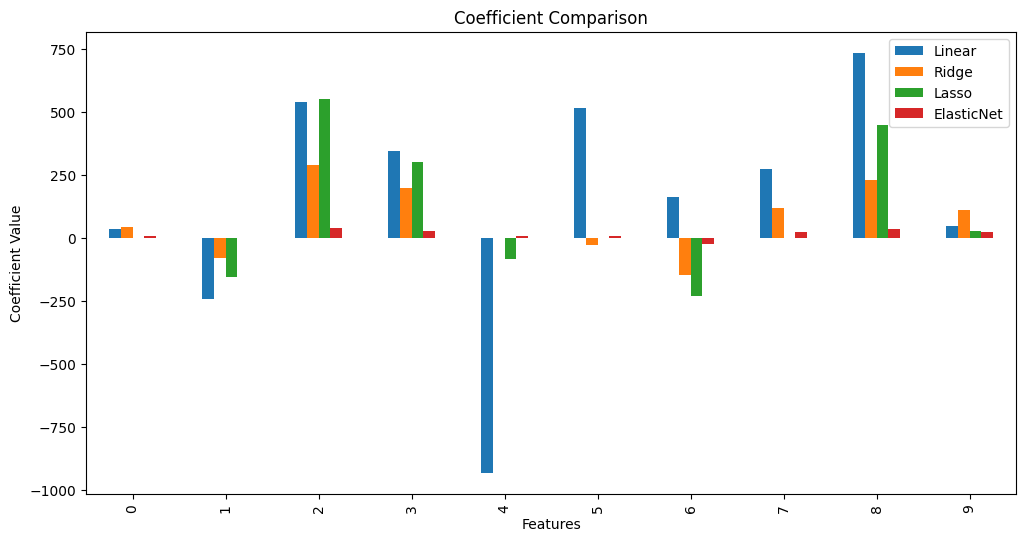

In [9]:
coefficients.plot(kind="bar", figsize=(12,6))
plt.title("Coefficient Comparison")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.show()
